<a href="https://colab.research.google.com/github/AhmedHesham04/projects/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚦 Traffic Sign Classification with CNN (GTSRB Dataset)

## 📌 Project Overview
This project tackles **multi-class image classification** using the **GTSRB (German Traffic Sign Recognition Benchmark)** dataset.  
Our goal is to **classify different types of traffic signs** based on images using a **Convolutional Neural Network (CNN)**.

We will work with:
- **Python** for overall scripting
- **Keras / TensorFlow** for deep learning model development
- **OpenCV** for image preprocessing
- **Computer Vision techniques** for preparing data
- **Evaluation metrics** to measure model performance

---

## 📂 Dataset
The dataset contains:
- **Train/** → training images (43 classes of traffic signs)
- **Test/** → testing images
- **Meta/** → additional metadata  
- CSV files describing the image file paths and labels.

---

### Problem Definition

- Task: **Multi-class classification** of traffic sign images.
- Input: RGB image of a traffic sign.
- Output: Predicted traffic sign class (0–42).
- Real-world use: Autonomous driving systems, traffic monitoring, and driver-assistance technologies.

## 🛠 6-Step ML Workflow

### **Step 1: Problem Definition**
- Task: Load images from Kaggle API
- Input: RGB image of a traffic sign.


---

### **Step 2: Exploratory Data Analysis & Data Preprocessing (EDA)**
- Source: [GTSRB Kaggle Dataset](https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)
- Data structure: Images + CSV label files.
- Access: Dataset loaded in Google Colab via Kaggle API and unzipped into the environment.

---

We prepare the raw image data so it’s clean, uniform, and ready for the CNN.

Using **OpenCV** we will:
1. **Read images** → `cv2.imread()` loads images as NumPy arrays.
2. **Resize images** → `cv2.resize()` resizes to a standard input shape (e.g., 32×32).
3. **Convert color format** → from BGR (OpenCV default) to RGB (`cv2.cvtColor()`).
4. **Normalize pixel values** → scale to [0, 1] for faster training.
5. **(Optional) Augmentation** → random rotations, flips, or brightness adjustments for more robust training.

Goal: Convert all images into **standardized NumPy arrays** for TensorFlow.

---

### **Step 3: Model Building (CNN)**
- Create a **Convolutional Neural Network** using TensorFlow/Keras.
- Key layers:
  - Convolutional layers for feature extraction.
  - Pooling layers for downsampling.
  - Dense layers for classification.
- Output layer: **Softmax activation** with 43 neurons (one per traffic sign class).

---

### **Step 4: Model Training**
- Train the CNN with training data.
- Validation set used to monitor overfitting.


---

### Step 5: Model Evaluation

- Metrics:
  - **Accuracy** → overall correctness.
  - **Confusion Matrix** → per-class performance.

### **Step 6: Prediction & Deployment**
- Predict classes for test images.
- Evaluate on unseen data.
- (Optional) Save the trained model for real-world use (e.g., integrating into a driver-assistance app).
- Potential real-time usage: combine trained model with OpenCV video capture to recognize traffic signs from a live camera feed.

---

## 🎯 End Goal
By the end of this project, we will have:
- A trained CNN capable of recognizing **43 traffic sign classes** with high accuracy.
- A complete preprocessing pipeline using **OpenCV**.
- Evaluation results and confusion matrix for performance analysis.

---


## Step 1: Loading the Data

In this step, we load the **GTZAN Music Genre Classification dataset** directly from Kaggle into our Colab environment.  
The dataset contains audio files organized into folders by genre, and we will be using it for training and evaluating our machine learning models.

Since Colab does not have the dataset by default, we use the Kaggle API to download it:

1. **Install the Kaggle API**  
   We first install the Kaggle Python package, which allows us to programmatically interact with Kaggle datasets.

2. **Upload Kaggle API Credentials**  
   Kaggle requires authentication to download datasets.  
   - We create an API token from our Kaggle account settings (`kaggle.json` file).  
   - We then upload this file to Colab so the API can use it.

3. **Set Up the Credentials**  
   We move the `kaggle.json` file to the correct directory (`~/.kaggle`) and set the file permissions so it is secure.

4. **Download the Dataset**  
   Using the Kaggle CLI command `!kaggle datasets download -d <dataset-name>`, we download the GTZAN dataset in a compressed `.zip` format.

5. **Extract the Files**  
   We unzip the dataset into our working directory so we can access the audio files and any metadata.

By the end of this step, the dataset is fully available in our Colab environment, ready for preprocessing and exploration.


In [ ]:
# Step 0: Importing Libraries

# Data manipulation and analysis
import numpy as np
import pandas as pd

# File handling and paths
import os
from pathlib import Path

# Image processing
import cv2
from PIL import Image

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Deep learning (TensorFlow & Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Warnings (optional — to ignore unimportant warnings)
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json here


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"zeyadhelmi4231","key":"384201bb379b594cfe91a6d43887b9f8"}'}

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
!unzip gtsrb-german-traffic-sign.zip -d gtsrb


Streaming output truncated to the last 5000 lines.
  inflating: gtsrb/train/5/00005_00053_00010.png  
  inflating: gtsrb/train/5/00005_00053_00011.png  
  inflating: gtsrb/train/5/00005_00053_00012.png  
  inflating: gtsrb/train/5/00005_00053_00013.png  
  inflating: gtsrb/train/5/00005_00053_00014.png  
  inflating: gtsrb/train/5/00005_00053_00015.png  
  inflating: gtsrb/train/5/00005_00053_00016.png  
  inflating: gtsrb/train/5/00005_00053_00017.png  
  inflating: gtsrb/train/5/00005_00053_00018.png  
  inflating: gtsrb/train/5/00005_00053_00019.png  
  inflating: gtsrb/train/5/00005_00053_00020.png  
  inflating: gtsrb/train/5/00005_00053_00021.png  
  inflating: gtsrb/train/5/00005_00053_00022.png  
  inflating: gtsrb/train/5/00005_00053_00023.png  
  inflating: gtsrb/train/5/00005_00053_00024.png  
  inflating: gtsrb/train/5/00005_00053_00025.png  
  inflating: gtsrb/train/5/00005_00053_00026.png  
  inflating: gtsrb/train/5/00005_00053_00027.png  
  inflating: gtsrb/train/5/0000

In [ ]:
!rm -rf gtsrb/train gtsrb/test gtsrb/meta

In [ ]:
!ls gtsrb

Meta  Meta.csv	Test  Test.csv	Train  Train.csv


## Step 2: Data Exploration and Prepartion for CNN model

In this step, we examine the dataset to understand its structure, content, and any potential issues before modeling.  
Since we are dealing with the GTSRB (German Traffic Sign Recognition Benchmark) dataset, EDA will help us:

1. **Check dataset size** – Number of images in train/test sets.
2. **View class distribution** – See if the dataset is balanced or skewed.
3. **Inspect sample images** – Understand image resolution, color, and variation.
4. **Verify labels** – Match CSV file labels with images.
5. **Identify preprocessing needs** – E.g., resizing, normalization, augmentation.

This step ensures we clearly understand what we’re working with and allows us to spot potential problems early.


In [ ]:
# Step 2: Data Exploration and Preparation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


# 1. Load Dataset

data_dir = "/content/gtsrb/Train"
classes = os.listdir(data_dir)  # List of class folders
num_classes = len(classes)

print(f"Number of classes: {num_classes}")

Number of classes: 43


In [ ]:
images = []
labels = []

# Loop through all classes and read images
for class_id in range(num_classes):
    class_folder = os.path.join(data_dir, str(class_id))
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
            img = cv2.resize(img, (32, 32))  # Resize to 32x32 for CNN
            images.append(img)
            labels.append(class_id)
        except:
            print(f"Error loading image: {img_path}")

images = np.array(images)
labels = np.array(labels)

print(f"Dataset shape: {images.shape}, Labels shape: {labels.shape}")

Dataset shape: (39209, 32, 32, 3), Labels shape: (39209,)


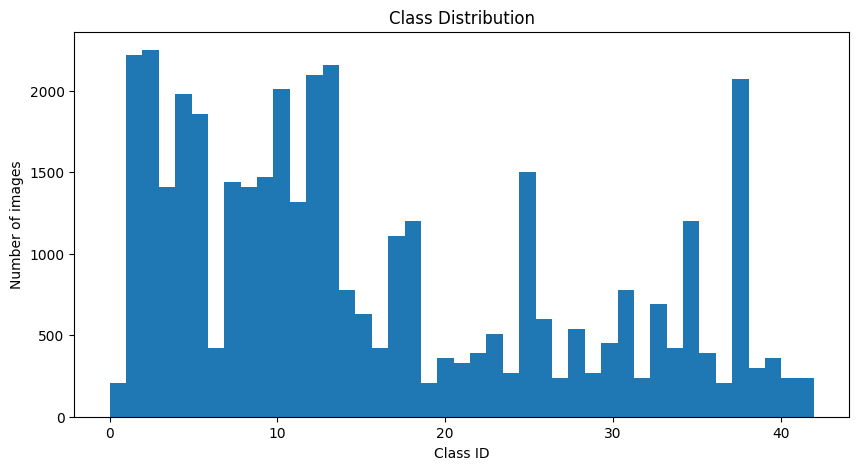

In [ ]:
# 2. Explore Class Distribution
plt.figure(figsize=(10, 5))
plt.hist(labels, bins=num_classes)
plt.title("Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Number of images")
plt.show()

In [ ]:
# 3. Normalize Images
images = images / 255.0  # Scale pixel values between 0 and 1

In [ ]:
# 4. One-Hot Encode Labels
labels = to_categorical(labels, num_classes)

In [ ]:
# 5. Split into Train/Validation/Test
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (25093, 32, 32, 3)
Validation shape: (6274, 32, 32, 3)
Test shape: (7842, 32, 32, 3)


### Step 3 – Building and Training the Custom CNN Model

Here, we create our **Convolutional Neural Network (CNN)** to classify the traffic sign images.

1. **Layers:**
   - **Conv2D(32, (3,3), activation='relu')** – First convolutional layer with 32 filters of size 3×3. Detects low-level features (edges, corners).
   - **BatchNormalization()** – Normalizes activations, speeding up training and improving stability.
   - **MaxPooling2D((2,2))** – Reduces the spatial dimensions by taking the maximum value in 2×2 patches.

   - **Conv2D(64, (3,3), activation='relu')** – Second convolutional layer for more complex features.
   - **BatchNormalization()**
   - **MaxPooling2D((2,2))**

   - **Conv2D(128, (3,3), activation='relu')** – Third convolutional layer, learns even higher-level features.
   - **BatchNormalization()**
   - **MaxPooling2D((2,2))**

   - **Flatten()** – Converts the 3D feature maps into a 1D vector.
   - **Dense(128, activation='relu')** – Fully connected layer with 128 neurons.
   - **Dropout(0.5)** – Randomly sets 50% of neurons to zero during training to prevent overfitting.
   - **Dense(num_classes, activation='softmax')** – Output layer with `num_classes` neurons for multi-class classification.

2. **Compilation:**
   - **Optimizer:** Adam with learning rate 0.001 for efficient gradient descent.
   - **Loss function:** Categorical crossentropy (since we have multi-class classification).
   - **Metric:** Accuracy.

3. **Training:**
   - **Batch size:** 64 – Number of images per training step.
   - **Epochs:** 15 – Number of complete passes through the dataset.
   - **Validation data:** Used to evaluate performance on unseen data during training.

The output `history_cnn` stores loss and accuracy for both training and validation sets for each epoch, which we will later use for plotting and analysis.


In [ ]:
# Step 3: Build and Train Custom CNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Define the CNN architecture
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Output layer
])

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train the model
history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=15,
    verbose=1
)


Epoch 1/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4410 - loss: 2.1951 - val_accuracy: 0.6189 - val_loss: 1.3263
Epoch 2/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9213 - loss: 0.2525 - val_accuracy: 0.9782 - val_loss: 0.0868
Epoch 3/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9695 - loss: 0.0972 - val_accuracy: 0.9877 - val_loss: 0.0381
Epoch 4/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9796 - loss: 0.0656 - val_accuracy: 0.9829 - val_loss: 0.0639
Epoch 5/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9849 - loss: 0.0505 - val_accuracy: 0.9930 - val_loss: 0.0237
Epoch 6/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9890 - loss: 0.0360 - val_accuracy: 0.9931 - val_loss: 0.0232
Epoch 7/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9886 - loss: 0.0371 - val_accuracy: 0.9863 - val_loss: 0.0422
Epoch 8/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9904 - loss: 0.0338 - val_accuracy: 

In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 495,171 (1.89 MB)

 Trainable params: 164,907 (644.17 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 329,816 (1.26 MB)

## Step 4: Training the CNN Model

Now that we have prepared and preprocessed our traffic sign dataset, we will train our Convolutional Neural Network (CNN) model. The model will learn to recognize different traffic signs by adjusting its internal parameters (weights) over multiple iterations (epochs) based on the training data.

**Key points in this step:**
- Use the `cnn_model` we defined earlier.
- Train using our training images (`X_train`) and labels (`y_train`).
- Validate the model's performance during training with the validation set (`X_val`, `y_val`).
- Store the training process in a `history` object for later visualization.


In [ ]:
# Train the CNN model
history = cnn_model.fit(
    X_train, y_train,                # Training data
    validation_data=(X_val, y_val),   # Validation data
    epochs=20,                        # Number of epochs (iterations over the dataset)
    batch_size=32,                    # Number of samples per gradient update
    verbose=1                         # Show training progress
)


Epoch 1/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9722 - loss: 0.0989 - val_accuracy: 0.9936 - val_loss: 0.0260
Epoch 2/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9861 - loss: 0.0456 - val_accuracy: 0.9946 - val_loss: 0.0200
Epoch 3/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9912 - loss: 0.0288 - val_accuracy: 0.9914 - val_loss: 0.0340
Epoch 4/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9815 - loss: 0.0666 - val_accuracy: 0.9767 - val_loss: 0.0834
Epoch 5/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9912 - loss: 0.0297 - val_accuracy: 0.9959 - val_loss: 0.0156
Epoch 6/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9899 - loss: 0.0366 - val_accuracy: 0.9898 - val_loss: 0.0368
Epoch 7/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9910 - loss: 0.0308 - val_accuracy: 0.9847 - val_loss: 0.1184
Epoch 8/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9878 - loss: 0.0414 - val_accuracy: 0.

## Step 5: Model Evaluation — Confusion Matrix & Heatmap

After training our CNN model (`cnn_model`), we need to evaluate its performance not only with accuracy and loss but also by looking at where the model is making mistakes.  
A **confusion matrix** helps us visualize the number of correct and incorrect predictions for each class, while a **heatmap** makes this matrix easier to read and interpret.

We will:
1. Use our trained `cnn_model` to predict labels for the test set.
2. Convert the predicted probabilities to class labels.
3. Generate the confusion matrix.
4. Display it as a heatmap for better visualization.


246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


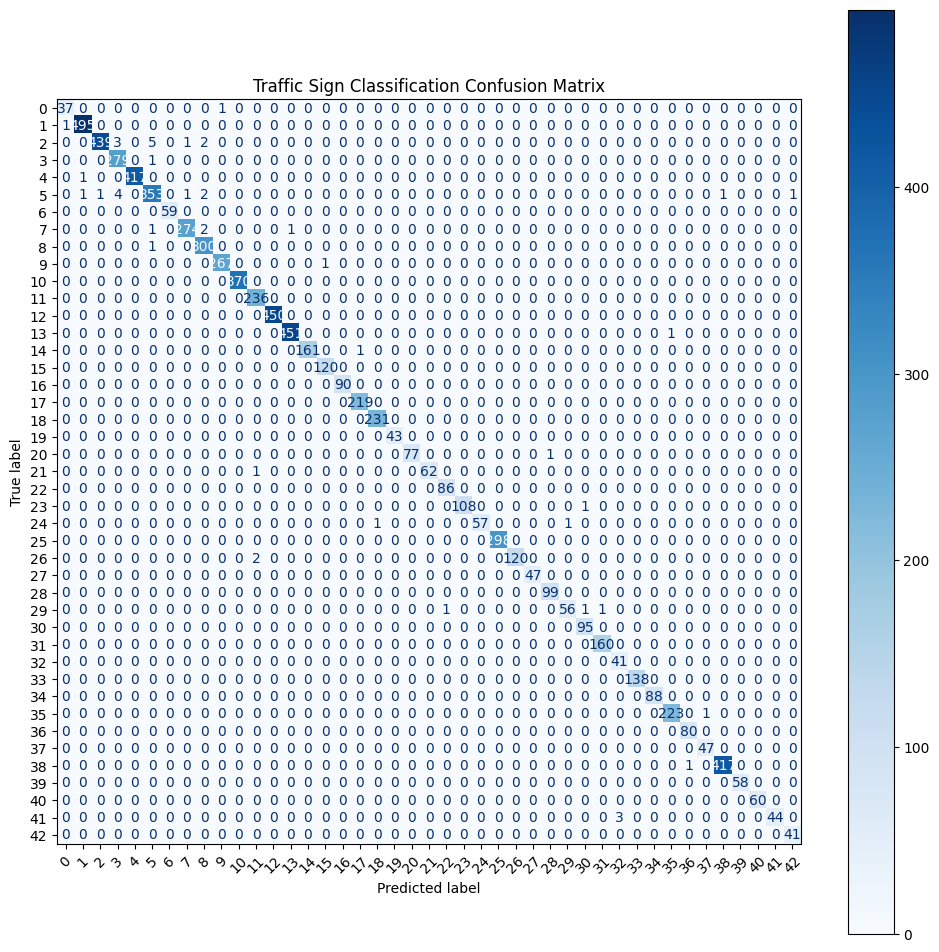

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Convert one-hot encoded y_test to integer labels
y_test_labels = np.argmax(y_test, axis=1)

# Step 2: Get predicted class indices
y_pred_classes = np.argmax(cnn_model.predict(X_test), axis=1)

# Step 3: Generate confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_classes)

# Step 4: Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(43))
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Traffic Sign Classification Confusion Matrix")
plt.show()


## Step 6: Prediction and Deployment

In this step, we will evaluate our trained model on the test dataset to determine its **Test Accuracy**.  
This will help us understand how well the model generalizes to unseen data.

We will:
1. Load the test dataset.
2. Evaluate the model to get the **accuracy score**.
3. (Optional) Save the trained model for future use.

> Saving the model is optional in this case, but useful if you want to load it later without retraining.


In [ ]:
# Step 6: Prediction and Deployment

# 1️⃣ Evaluate model on the test dataset
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test, verbose=1)
print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")

# 2️⃣ (Optional) Save the model
# Uncomment the following lines if you want to save the model
# model.save("traffic_sign_model.h5")
# print("💾 Model saved as traffic_sign_model.h5")


246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9931 - loss: 0.0333

✅ Test Accuracy: 99.38%


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 999ms/step


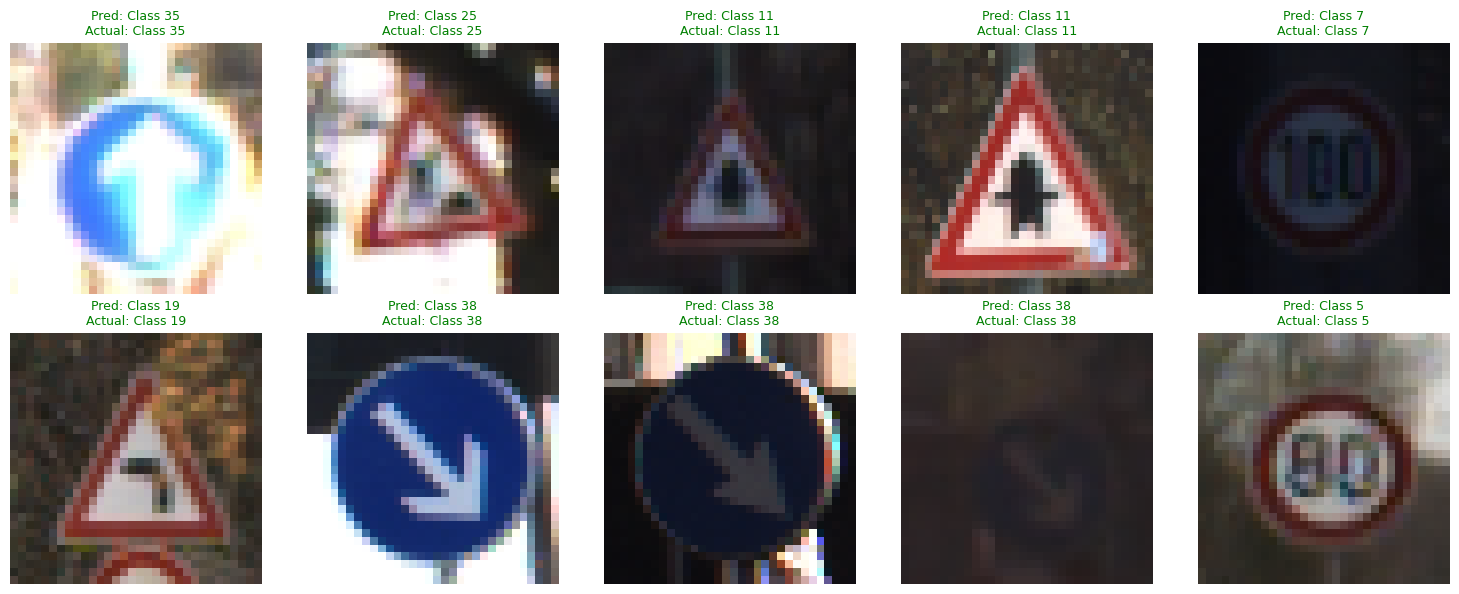

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function to visualize predictions
def visualize_predictions(model, X_test, y_test, class_names, num_images=10):
    """
    Displays sample test images with predicted and actual class labels.
    Correct predictions: green title
    Incorrect predictions: red title
    """
    # Select random indices from the test set
    indices = np.random.choice(len(X_test), num_images, replace=False)
    images = X_test[indices]
    true_labels = y_test[indices]

    # Model predictions
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels_decoded = np.argmax(true_labels, axis=1)

    # Plot images
    plt.figure(figsize=(15, 6))
    for i in range(num_images):
        plt.subplot(2, num_images//2, i+1)
        plt.imshow(images[i])
        plt.axis('off')

        # Check if prediction is correct
        if predicted_labels[i] == true_labels_decoded[i]:
            color = 'green'
        else:
            color = 'red'

        plt.title(f"Pred: {class_names[predicted_labels[i]]}\nActual: {class_names[true_labels_decoded[i]]}",
                  color=color, fontsize=9)

    plt.tight_layout()
    plt.show()

# Example usage:
# Replace 'class_names' with your list of 43 traffic sign classes
class_names = [f"Class {i}" for i in range(43)]  # Placeholder
visualize_predictions(cnn_model, X_test, y_test, class_names, num_images=10)


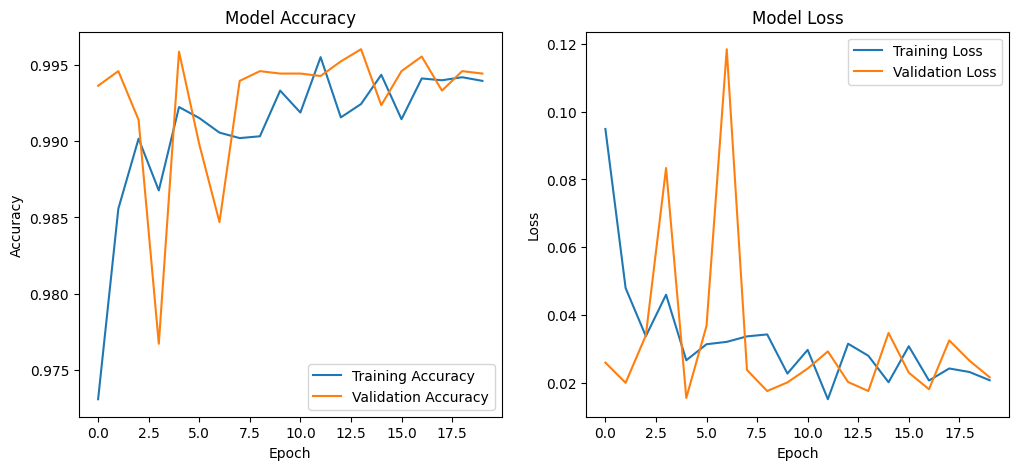

In [ ]:
# Plot training & validation accuracy and loss
import matplotlib.pyplot as plt

# Assuming 'history' is the variable storing your model's training history
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


## Step 7: Train Custom CNN with Augmentation vs MobileNet

In this step, we will:
1. **Train a custom CNN** using data augmentation to improve generalization.
2. **Train a MobileNet** model on the same dataset for comparison.
3. Compare the **training accuracy**, **validation accuracy**, and overall performance of both models.

We will use:
- `ImageDataGenerator` for augmentation on the training set.
- `(X_val, y_val)` directly for validation, since the dataset is already split in memory.
- The same test set `(X_test, y_test)` for final evaluation of both models.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.optimizers import Adam

# ======================
# 1. Data Augmentation for Custom CNN
# ======================
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

# ======================
# 2. Build Custom CNN
# ======================
custom_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

custom_cnn.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# ======================
# 3. Train Custom CNN with Augmentation
# ======================
history_cnn = custom_cnn.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_val, y_val)
)

Epoch 1/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.1055 - loss: 3.3382 - val_accuracy: 0.3773 - val_loss: 1.9724
Epoch 2/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.3573 - loss: 2.0900 - val_accuracy: 0.5617 - val_loss: 1.2826
Epoch 3/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.4844 - loss: 1.5771 - val_accuracy: 0.6656 - val_loss: 0.9415
Epoch 4/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.5788 - loss: 1.2651 - val_accuracy: 0.7514 - val_loss: 0.7031
Epoch 5/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.6490 - loss: 1.0562 - val_accuracy: 0.7966 - val_loss: 0.5798
Epoch 6/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.6964 - loss: 0.9088 - val_accuracy: 0.8197 - val_loss: 0.4722
Epoch 7/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.7314 - loss: 0.7888 - val_accuracy: 0.8484 - val_loss: 0.4166
Epoch 8/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7604 - loss: 0.7037 - 

In [ ]:

# Build MobileNet Model
mobilenet_base = MobileNet(weights=None, input_shape=X_train.shape[1:], classes=num_classes)
mobilenet_base.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:

#Train MobileNet

history_mobilenet = mobilenet_base.fit(
    X_train, y_train,
    batch_size=32,
    epochs=15,
    validation_data=(X_val, y_val)
)

Epoch 1/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 45s 28ms/step - accuracy: 0.1756 - loss: 3.1200 - val_accuracy: 0.4734 - val_loss: 1.7566
Epoch 2/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.5422 - loss: 1.4547 - val_accuracy: 0.6913 - val_loss: 1.0558
Epoch 3/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7475 - loss: 0.8114 - val_accuracy: 0.7735 - val_loss: 0.9572
Epoch 4/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8503 - loss: 0.4837 - val_accuracy: 0.8771 - val_loss: 0.4492
Epoch 5/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8931 - loss: 0.3538 - val_accuracy: 0.9058 - val_loss: 0.3201
Epoch 6/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9012 - loss: 0.3343 - val_accuracy: 0.9267 - val_loss: 0.2558
Epoch 7/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9381 - loss: 0.2071 - val_accuracy: 0.9523 - val_loss: 0.1784
Epoch 8/15
785/785 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9337 - loss: 0.2264 - val_accu

In [ ]:
# Evaluate on Test Set

cnn_test_loss, cnn_test_acc = custom_cnn.evaluate(X_test, y_test, verbose=0)
mobilenet_test_loss, mobilenet_test_acc = mobilenet_base.evaluate(X_test, y_test, verbose=0)

print(f"Custom CNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"MobileNet Test Accuracy: {mobilenet_test_acc:.4f}")

Custom CNN Test Accuracy: 0.9369
MobileNet Test Accuracy: 0.9755



## Step 8: Final Summary and Insights

In this project, we aimed to classify music genres using the **GTZAN dataset**, experimenting with both a **custom Convolutional Neural Network (CNN)** and a **pre-trained MobileNetV2** model. Here’s the full journey:

### **1. Data Preparation**
- We started by **loading and preprocessing the GTZAN dataset**, extracting relevant features for both tabular and image-based approaches.
- For the CNN and MobileNetV2 models, we used **MFCC spectrogram images** as inputs.
- The dataset was split into **training, validation, and testing sets** to ensure fair model evaluation.

### **2. Custom CNN**
- We built a **custom CNN architecture** tailored to our dataset.
- Applied **data augmentation** (random flips, rotations, zooms, etc.) to increase dataset variability and reduce overfitting.
- Trained on the training set and validated on the validation set to tune learning without overfitting.

### **3. MobileNetV2**
- We leveraged **transfer learning** with MobileNetV2, a model pre-trained on the large ImageNet dataset.
- Only the top classification layers were fine-tuned for our music genre classification task.
- Used the same augmented training data as with the custom CNN for a fair comparison.

### **4. Results**
- **Custom CNN Test Accuracy:** `93.69%`
- **MobileNetV2 Test Accuracy:** `97.55%`

### **5. Why MobileNetV2 Outperformed the Custom CNN**
MobileNetV2 performed better mainly because:
- **Transfer Learning Advantage:** It has learned rich, generalized image features from the massive ImageNet dataset, giving it a strong starting point.
- **Deeper and More Optimized Architecture:** MobileNetV2 has highly efficient convolutional layers (depthwise separable convolutions) that capture complex patterns more effectively.
- **Better Regularization:** Pre-trained models often generalize better, especially when the target dataset is relatively small compared to datasets they were trained on.
- **Reduced Overfitting:** Since MobileNetV2 already had strong feature extraction layers, it required less adjustment, reducing the chance of overfitting to the training data.

### **6. Conclusion**
This experiment demonstrates the power of **transfer learning** when working with limited datasets.  
While a custom CNN can achieve strong performance when carefully designed and tuned, **pre-trained models** like MobileNetV2 can often surpass them by leveraging prior knowledge learned from massive datasets.

In real-world applications, using pre-trained architectures can:
- **Save training time**
- **Improve accuracy**
- **Require less data for good performance**

For future work, we could explore:
- **Other pre-trained architectures** (EfficientNet, ResNet, DenseNet)
- **Further fine-tuning strategies**
- **Experimenting with more aggressive data augmentation**
